# Bank Customer Intelligence System
## Supervised Learning: Term Deposit Subscription Classification

This notebook prepares the Bank Marketing Dataset, trains classification models, and evaluates their ability to predict whether a customer will subscribe to a term deposit.

## 1. Import Required Libraries

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from xgboost import XGBClassifier

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectPercentile, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

## 2. Load the Dataset

In [2]:
DATA_PATH = Path("../dataset/bank-full.csv")

df = pd.read_csv(
    DATA_PATH,
    sep=";"
)

df.shape

(45211, 17)

## 3. Remove the Leakage Feature

In [3]:
model_df = df.drop(
    columns=["duration"]
).copy()

model_df.shape

(45211, 16)

In [4]:
"duration" in model_df.columns

False

## 4. Separate Features and Target

In [5]:
deployment_features = [
    "age",
    "job",
    "marital",
    "education",
    "balance",
    "housing",
    "loan",
    "campaign"
]

X = model_df[
    deployment_features
].copy()

y = model_df["y"].map({
    "no": 0,
    "yes": 1
})

In [6]:
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (45211, 8)
Target shape: (45211,)


In [7]:
y.value_counts()

y
0    39922
1     5289
Name: count, dtype: int64

## 5. Create Training and Testing Sets

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [9]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (36168, 8)
X_test: (9043, 8)
y_train: (36168,)
y_test: (9043,)


In [10]:
print(
    "Training target percentages:"
)
display(
    y_train.value_counts(
        normalize=True
    ).mul(100).round(2)
)

print(
    "Testing target percentages:"
)
display(
    y_test.value_counts(
        normalize=True
    ).mul(100).round(2)
)

Training target percentages:


y
0    88.3
1    11.7
Name: proportion, dtype: float64

Testing target percentages:


y
0    88.3
1    11.7
Name: proportion, dtype: float64

## 6. Build the Preprocessing Pipeline

In [11]:
numerical_features = (
    X_train
    .select_dtypes(include="number")
    .columns
    .tolist()
)

categorical_features = (
    X_train
    .select_dtypes(include="object")
    .columns
    .tolist()
)

In [12]:
print("Numerical features:")
display(numerical_features)

print("Categorical features:")
display(categorical_features)

print(
    "Total features:",
    len(numerical_features)
    + len(categorical_features)
)

Numerical features:


['age', 'balance', 'campaign']

Categorical features:


['job', 'marital', 'education', 'housing', 'loan']

Total features: 8


In [13]:
numerical_transformer = Pipeline(
    steps=[
        (
            "scaler",
            RobustScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_transformer,
            numerical_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ],
    remainder="drop"
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

In [15]:
feature_selector = SelectPercentile(
    score_func=f_classif,
    percentile=80
)

feature_selector

,"percentile percentile: int, default=10Percent of features to keep.",80
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function f_c...001960C235BC0>


## 7. Train Classification Models
### 7.1 Logistic Regression

In [16]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "feature_selection",
            clone(feature_selector)
        ),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                solver="liblinear",
                random_state=42
            )
        )
    ]
)

logistic_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_thre

In [17]:
logistic_pipeline.fit(
    X_train,
    y_train
)

print(
    "Logistic Regression training completed."
)

Logistic Regression training completed.


#### Logistic Regression Evaluation

In [18]:
logistic_predictions = (
    logistic_pipeline.predict(X_test)
)

In [19]:
logistic_results = pd.Series({
    "Accuracy": accuracy_score(
        y_test,
        logistic_predictions
    ),
    "Precision": precision_score(
        y_test,
        logistic_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        logistic_predictions,
        zero_division=0
    ),
    "F1-Score": f1_score(
        y_test,
        logistic_predictions,
        zero_division=0
    )
}).round(4)

logistic_results

Accuracy     0.6376
Precision    0.1917
Recall       0.6522
F1-Score     0.2963
dtype: float64

In [20]:
logistic_confusion_matrix = confusion_matrix(
    y_test,
    logistic_predictions
)

logistic_confusion_matrix

array([[5076, 2909],
       [ 368,  690]])

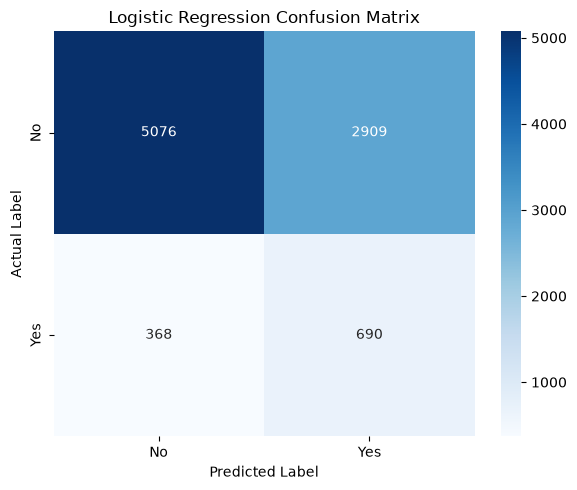

In [21]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    logistic_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.title(
    "Logistic Regression Confusion Matrix"
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

#### Logistic Regression Findings

- Accuracy: **0.6376**
- Precision: **0.1917**
- Recall: **0.6522**
- F1-score: **0.2963**
- The model correctly identified **5,076 non-subscribers** and **690 subscribers**.
- It incorrectly classified **2,909 non-subscribers** as subscribers.
- It missed **368 actual subscribers**.
- Logistic Regression achieved the highest recall, but it produced many false-positive predictions.

### 7.2 Random Forest

In [ ]:
random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "feature_selection",
            clone(feature_selector)
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                min_samples_leaf=2,
                max_features="sqrt",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_thre

In [ ]:
random_forest_pipeline.fit(
    X_train,
    y_train
)

print(
    "Random Forest training completed."
)

Random Forest training completed.


In [ ]:
random_forest_predictions = (
    random_forest_pipeline.predict(X_test)
)

In [ ]:
random_forest_results = pd.Series({
    "Accuracy": accuracy_score(
        y_test,
        random_forest_predictions
    ),
    "Precision": precision_score(
        y_test,
        random_forest_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        random_forest_predictions,
        zero_division=0
    ),
    "F1-Score": f1_score(
        y_test,
        random_forest_predictions,
        zero_division=0
    )
}).round(4)

random_forest_results

Accuracy     0.7997
Precision    0.2733
Recall       0.4291
F1-Score     0.3339
dtype: float64

In [ ]:
random_forest_confusion_matrix = (
    confusion_matrix(
        y_test,
        random_forest_predictions
    )
)

random_forest_confusion_matrix

array([[6778, 1207],
       [ 604,  454]])

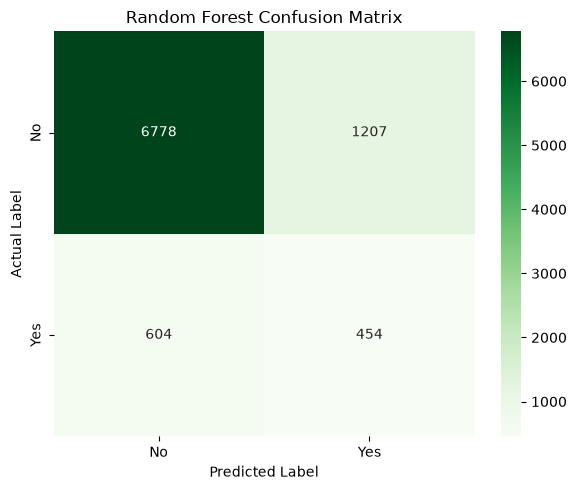

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    random_forest_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.title(
    "Random Forest Confusion Matrix"
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

#### Random Forest Findings

- Accuracy: **0.7997**
- Precision: **0.2733**
- Recall: **0.4291**
- F1-score: **0.3339**
- The model correctly identified **6,778 non-subscribers** and **454 subscribers**.
- It incorrectly classified **1,207 non-subscribers** as subscribers.
- It missed **604 actual subscribers**.
- Random Forest achieved the highest F1-score among the evaluated classification models.
- Therefore, Random Forest was selected as the final classification model.

### 7.3 XGBoost

In [30]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = (
    negative_count / positive_count
)

print(
    "Scale positive weight:",
    round(scale_pos_weight, 2)
)

Scale positive weight: 7.55


In [31]:
xgboost_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "feature_selection",
            clone(feature_selector)
        ),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

xgboost_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_thre

In [32]:
xgboost_pipeline.fit(
    X_train,
    y_train
)

print(
    "XGBoost training completed."
)

XGBoost training completed.


In [33]:
xgboost_predictions = (
    xgboost_pipeline.predict(X_test)
)

In [34]:
xgboost_results = pd.Series({
    "Accuracy": accuracy_score(
        y_test,
        xgboost_predictions
    ),
    "Precision": precision_score(
        y_test,
        xgboost_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        xgboost_predictions,
        zero_division=0
    ),
    "F1-Score": f1_score(
        y_test,
        xgboost_predictions,
        zero_division=0
    )
}).round(4)

xgboost_results

Accuracy     0.7143
Precision    0.2265
Recall       0.5974
F1-Score     0.3285
dtype: float64

In [35]:
xgboost_confusion_matrix = confusion_matrix(
    y_test,
    xgboost_predictions
)

xgboost_confusion_matrix

array([[5827, 2158],
       [ 426,  632]])

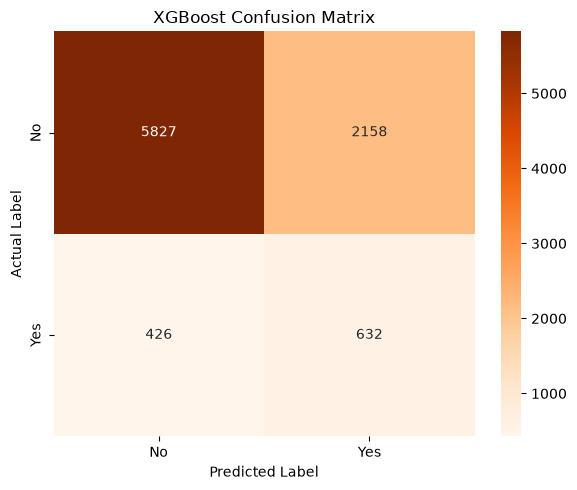

In [36]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    xgboost_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

#### XGBoost Findings

- Accuracy: **0.7143**
- Precision: **0.2265**
- Recall: **0.5974**
- F1-score: **0.3285**
- The model correctly identified **5,827 non-subscribers** and **632 subscribers**.
- It incorrectly classified **2,158 non-subscribers** as subscribers.
- It missed **426 actual subscribers**.
- XGBoost achieved higher recall than Random Forest, but its F1-score was slightly lower.

## 8. Model Comparison

In [38]:
model_comparison = pd.DataFrame({
    "Logistic Regression": logistic_results,
    "Random Forest": random_forest_results,
    "XGBoost": xgboost_results
}).transpose()

model_comparison = model_comparison.sort_values(
    by="F1-Score",
    ascending=False
)

model_comparison

,Accuracy,Precision,Recall,F1-Score
Random Forest,0.7997,0.2733,0.4291,0.3339
XGBoost,0.7143,0.2265,0.5974,0.3285
Logistic Regression,0.6376,0.1917,0.6522,0.2963


In [39]:
comparison_plot_data = (
    model_comparison
    .reset_index()
    .rename(columns={"index": "Model"})
    .melt(
        id_vars="Model",
        var_name="Metric",
        value_name="Score"
    )
)

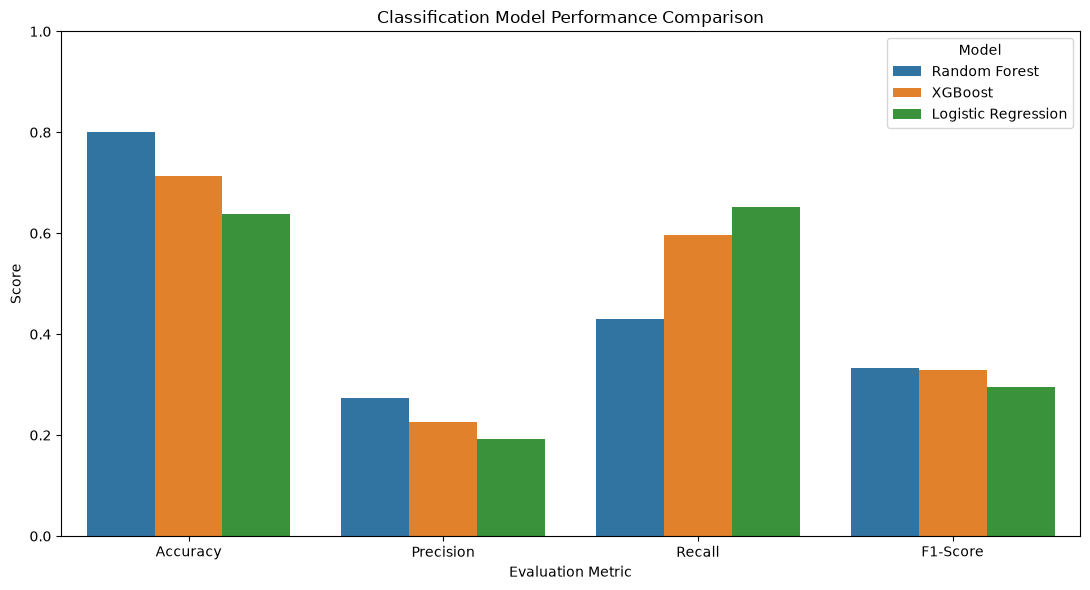

In [40]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=comparison_plot_data,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title(
    "Classification Model Performance Comparison"
)
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

### Model Comparison Findings

- Random Forest achieved the highest accuracy: **0.7997**.
- Random Forest achieved the highest precision: **0.2733**.
- Logistic Regression achieved the highest recall: **0.6522**.
- Random Forest achieved the highest F1-score: **0.3339**.
- XGBoost achieved an F1-score of **0.3285**, which was slightly lower than Random Forest.
- Logistic Regression achieved the lowest F1-score: **0.2963**.
- Based on the proposal's model-selection rule, F1-score is the primary metric.

## 9. Best Model Selection

In [41]:
best_model_name = (
    model_comparison["F1-Score"].idxmax()
)

best_f1_score = (
    model_comparison.loc[
        best_model_name,
        "F1-Score"
    ]
)

print("Best model:", best_model_name)
print("Best F1-score:", best_f1_score)

Best model: Random Forest
Best F1-score: 0.3339


In [42]:
model_pipelines = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": random_forest_pipeline,
    "XGBoost": xgboost_pipeline,
}

best_classification_pipeline = model_pipelines[
    best_model_name
]

### Selected Model

**Random Forest** was selected as the final classification model because it achieved the highest F1-score of **0.3339**. It also achieved the highest accuracy of **0.7997** and the highest precision of **0.2733** among the three models.

Logistic Regression achieved the highest recall of **0.6522**, but the submitted proposal defines F1-score as the main model-selection metric. Therefore, Random Forest is the selected model for deployment.

## 10. Retrain and Save the Final Model

In [44]:
final_classification_pipeline = clone(
    random_forest_pipeline
)

final_classification_pipeline.fit(
    X,
    y
)

print(
    "Final classification model retraining completed."
)

Final classification model retraining completed.


In [45]:
MODEL_DIR = Path("../backend/models")

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [46]:
classification_model_path = (
    MODEL_DIR / "classification_model.pkl"
)

joblib.dump(
    final_classification_pipeline,
    classification_model_path
)

['..\\backend\\models\\classification_model.pkl']

In [47]:
fitted_preprocessing_pipeline = (
    final_classification_pipeline
    .named_steps["preprocessor"]
)

preprocessing_pipeline_path = (
    MODEL_DIR / "preprocessing_pipeline.pkl"
)

joblib.dump(
    fitted_preprocessing_pipeline,
    preprocessing_pipeline_path
)

['..\\backend\\models\\preprocessing_pipeline.pkl']

In [48]:
print(
    "Classification model saved:",
    classification_model_path.exists()
)

print(
    "Preprocessing pipeline saved:",
    preprocessing_pipeline_path.exists()
)

Classification model saved: True
Preprocessing pipeline saved: True
